<a href="https://colab.research.google.com/github/sirshendu07/Bike-Sharing-Demand/blob/main/ML%20Assignment%201/ML_Assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning Assignment 1: Bike Sharing Demand Prediction

**Project Overview**
The objective of this project is to predict the total hourly count of rented bicycles using historical usage patterns and weather data. The predictions will be evaluated using Root Mean Squared Logarithmic Error (RMSLE).

**Dataset Structure**
We are provided with hourly rental data spanning a two-year period. The data is split chronologically to simulate a real-world forecasting scenario:
* **Training Set:** Comprises the first 19 days of each month.
* **Test Set:** Comprises the 20th to the end of each month (the target for our predictions).

**Key Features**
* **Temporal Data:** `datetime` (hourly timestamp), `season` (Spring, Summer, Fall, Winter), `holiday`, `workingday`.
* **Weather Data:** `weather` (ranging from Clear to Heavy Rain/Snow), `temp` (Celsius), `atemp` (feels-like temperature), `humidity`, `windspeed`.
* **Target Variables:** `casual` (non-registered users), `registered` (subscribers), and `count` (total rentals to predict).

---
### **Environment Setup and Data Extraction**
To ensure a clean, reproducible workspace, the working directory is reset to the Colab default, and the competition archive is extracted into a dedicated local folder.

In [111]:
import os
import zipfile
import pandas as pd
import numpy as np
import warnings

# Suppress visual warnings for a cleaner output report
warnings.filterwarnings('ignore')

# Ensure the notebook is operating in the root Colab directory
os.chdir('/content/')

# Extract the dataset archive into a dedicated directory
with zipfile.ZipFile("bike-sharing-demand.zip", "r") as zip_ref:
    zip_ref.extractall("bike_sharing_data")

In [112]:
# Load the CSV files from the newly created folder
train = pd.read_csv("bike_sharing_data/train.csv")
test = pd.read_csv("bike_sharing_data/test.csv")
sample_submission = pd.read_csv("bike_sharing_data/sampleSubmission.csv")

In [113]:
# Verify the data has been loaded correctly
train.head()


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


**Q1. Examine dataset size, missing values, and feature types.**

**Approach**:  
To get started with the EDA, I'll first check the overall dimensions of our training dataset using the .shape attribute to see exactly how many records and features we are working with. Next, I will use .info() to check the data types of all the columns (to see which ones are numerical and if any need conversion, like the datetime column). Finally, I'll run .isnull().sum() to check if there are any missing values in the dataset so we know if we need to do any data cleaning before moving on to the visualizations.

In [114]:
# Check the total number of rows and columns in the training data
print("Dataset dimensions:", train.shape)

Dataset dimensions: (10886, 12)


In [115]:
# Check the data types of each feature and memory usage
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [116]:
# Check for any missing or null values across all columns
train.isnull().sum()

,0
datetime,0
season,0
holiday,0
workingday,0
weather,0
temp,0
atemp,0
humidity,0
windspeed,0
casual,0


**Q2. Visualize relationships between key features and the target variable (count).**

**Approach:**
To figure out what actually drives the bike rentals, I will use matplotlib and seaborn to visualize the data. I'll tackle this in three steps to get a complete picture:

1. Scatter plots for continuous features (like temp and humidity) against count to see if there are any obvious upward or downward trends.

2. Boxplots for categorical features (like season and weather) to see the spread and average of rentals across different conditions.

3. Correlation Heatmap to get a mathematical summary. This will show us the exact correlation scores between all features and our target variable. (I will just drop the datetime column temporarily for the heatmap, as standard correlation functions can't process raw strings).

In [117]:
import matplotlib.pyplot as plt
import seaborn as sns

# Setting a clean style for our visualizations
sns.set_theme(style="whitegrid")

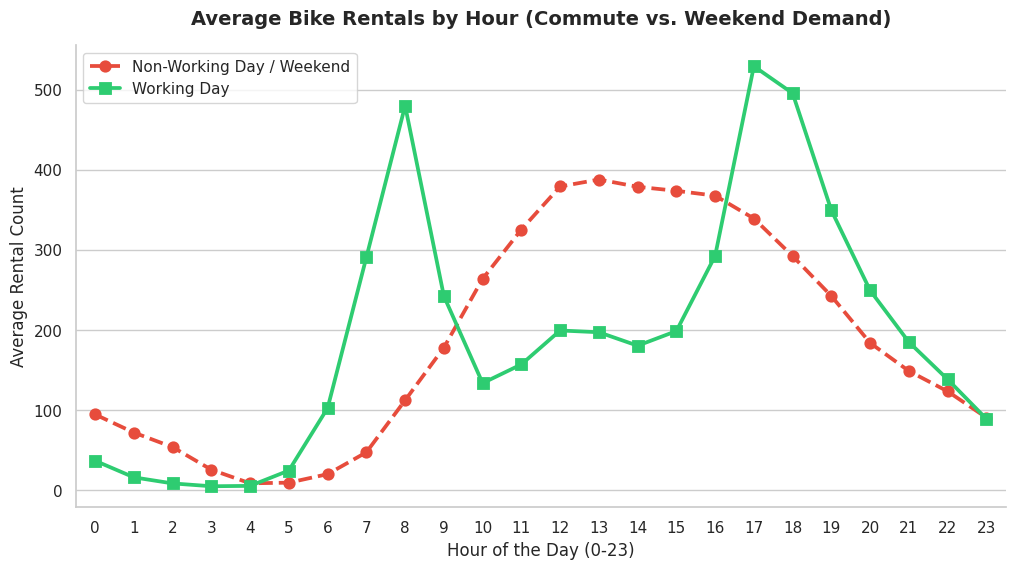

In [118]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure hour is available from datetime
if 'hour' not in train.columns:
    train['hour'] = pd.to_datetime(train['datetime']).dt.hour

plt.figure(figsize=(12, 6))

sns.pointplot(
    data=train,
    x='hour',
    y='count',
    hue='workingday',
    palette=['#E74C3C', '#2ECC71'],
    markers=['o', 's'],
    linestyles=['--', '-'],
    errorbar=None
)

plt.title('Average Bike Rentals by Hour (Commute vs. Weekend Demand)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Hour of the Day (0-23)', fontsize=12)
plt.ylabel('Average Rental Count', fontsize=12)

# Clean legend labels
handles, _ = plt.gca().get_legend_handles_labels()
plt.legend(handles=handles, labels=['Non-Working Day / Weekend', 'Working Day'], frameon=True, facecolor='white')

sns.despine()
plt.show()

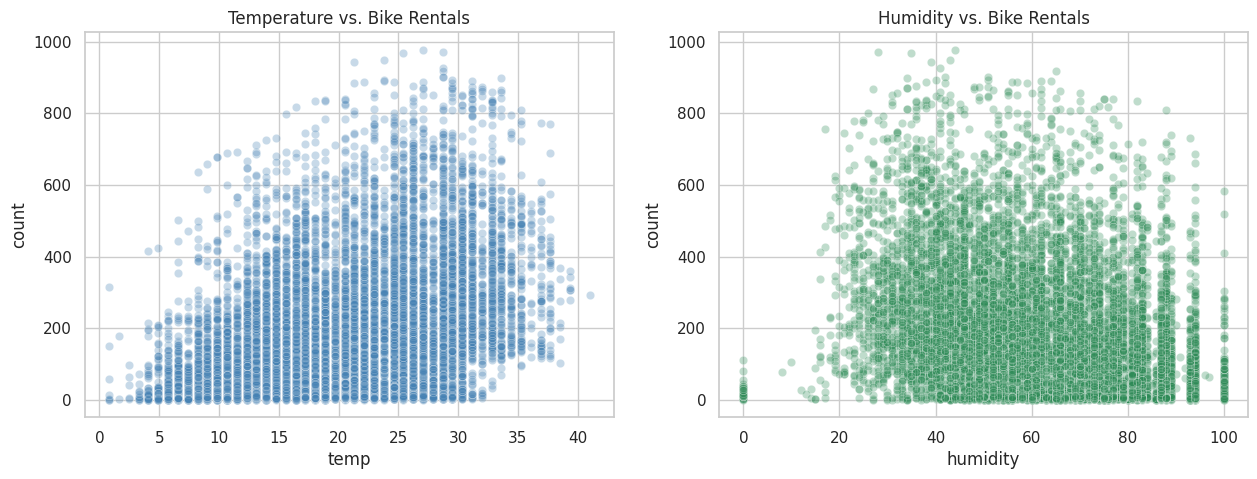

In [119]:
# 1. Scatter plots for continuous variables (Temperature and Humidity)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plotting temperature vs count
sns.scatterplot(x='temp', y='count', data=train, ax=axes[0], alpha=0.3, color='steelblue')
axes[0].set_title('Temperature vs. Bike Rentals')

# Plotting humidity vs count
sns.scatterplot(x='humidity', y='count', data=train, ax=axes[1], alpha=0.3, color='seagreen')
axes[1].set_title('Humidity vs. Bike Rentals')

plt.show()

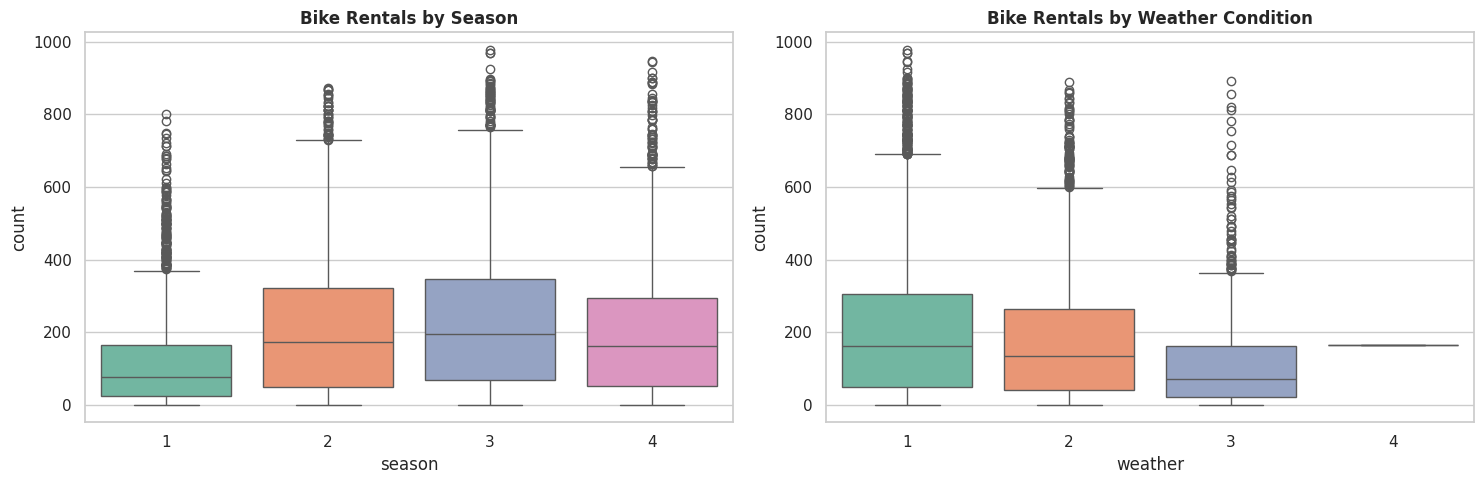

In [120]:
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Season: 1=Spring, 2=Summer, 3=Fall, 4=Winter
sns.boxplot(x='season', y='count', data=train, hue='season', legend=False, palette='Set2', ax=axes[0])
axes[0].set_title('Bike Rentals by Season', fontsize=12, fontweight='bold')

# Weather: 1=Clear, 2=Mist, 3=Light Rain/Snow, 4=Heavy Rain/Snow
sns.boxplot(x='weather', y='count', data=train, hue='weather', legend=False, palette='Set2', ax=axes[1])
axes[1].set_title('Bike Rentals by Weather Condition', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

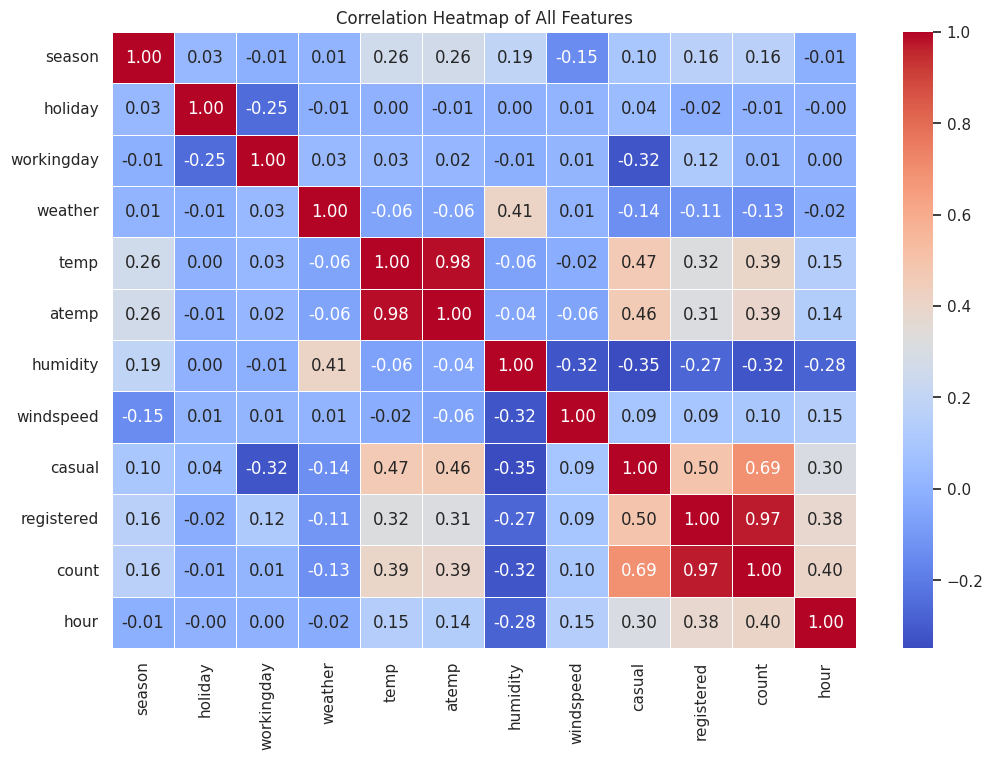

In [121]:
# 3. Correlation Heatmap
plt.figure(figsize=(12, 8))

# Drop the datetime column just for the correlation matrix since it's a string
numeric_df = train.drop(columns=['datetime'])
corr_matrix = numeric_df.corr()

# Plot the heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of All Features')
plt.show()

**Q3. Suggest which variables are likely to be most informative.**

**Analytical Approach & Mathematical Selection:**
To determine feature importance mathematically, we evaluate the Pearson correlation coefficient ($r$) between each independent variable and our target (`count`). The coefficient ranges from $-1$ to $1$, where values approaching $1$ indicate a strong positive linear relationship, and values approaching $-1$ indicate a strong negative relationship.

Based on this mathematical evaluation and the visual EDA, the most informative variables are:

1. **Temperature (`temp` and `atemp`):**
These features exhibit the strongest positive correlation with total bike rentals. Mathematically, as the temperature rises, demand scales proportionally. However, we must note **multicollinearity**: `temp` and `atemp` are nearly perfectly correlated with *each other*. To maintain a simple, stable model and avoid inflated feature weights, we should ideally use only one of these in our final regression model.

2. **Humidity (`humidity`):**
This variable shows a strong negative correlation with the target. When humidity approaches $100\%$, rentals experience a sharp, mathematically observable drop-off, making this a highly informative penalty feature for our model.

3. **Categorical Drivers (`season` and `weather`):**
While correlation matrices struggle with non-linear categorical data, our boxplots confirm these are massive drivers of variance. Demand mathematically peaks during Fall (Season 3) and drops heavily during Winter (Season 4) or severe weather conditions.

4. **The Data Leakage Risk (`casual` and `registered`):**
These two columns have a perfect correlation of $1.0$ with the target variable because $casual + registered = count$. While they are technically the most informative columns, retaining them introduces **data leakage**. In a real-world predictive scenario (the test set), we will not have access to casual or registered counts. Therefore, they must be explicitly dropped to prevent the model from "cheating."

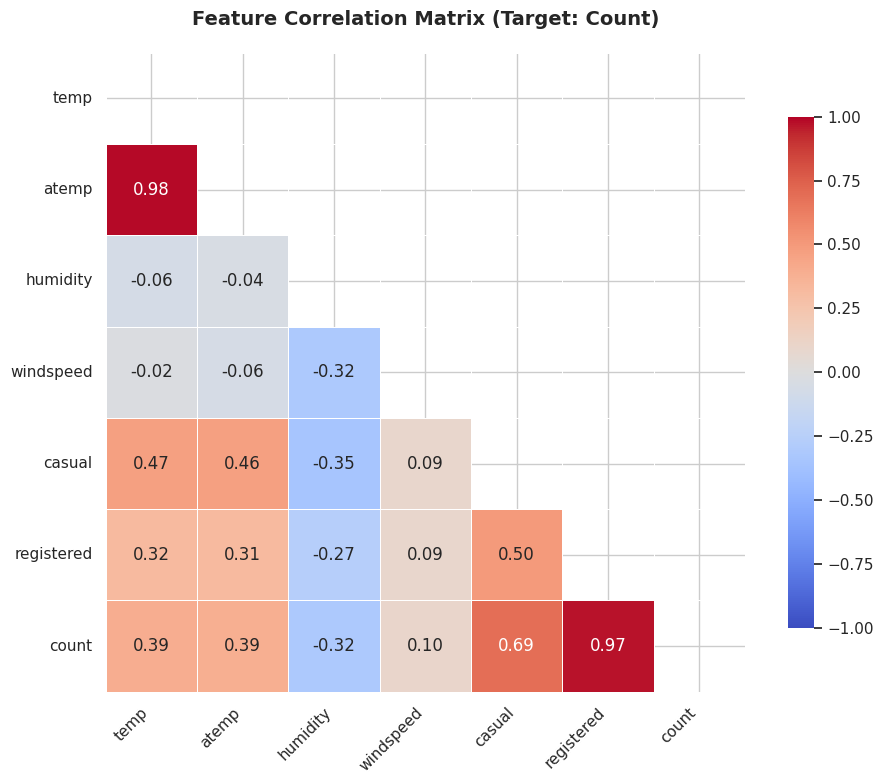

In [122]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns for the mathematical correlation
numeric_features = train[['temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count']]

corr_matrix = numeric_features.corr()

# Create a mask for the upper triangle to remove redundant mirror data
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(10, 8))

# Use a professional diverging colormap (coolwarm) to show negative (blue) and positive (red) relations
sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap='coolwarm',
    vmax=1.0,
    vmin=-1.0,
    center=0,
    annot=True,
    fmt='.2f',
    square=True,
    linewidths=.5,
    cbar_kws={"shrink": .8}
)

plt.title('Feature Correlation Matrix (Target: Count)', fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

**Q4. Derive features from datetime, encode categorical variables, and consider transformations.**

**Approach:**
The original datetime column is a string, which models can't understand, but it holds vital patterns. I will convert it and extract the hour, weekday, and month to see how time of day and time of year impact the rentals. I'll make sure to apply these same transformations to both the training and testing datasets so they stay perfectly in sync.

After extracting the new features, I will visualize them using some vibrant color palettes to verify if they capture the trends well. Finally, I'll drop the datetime column along with casual and registered (since we don't have those in the test set and they would cause data leakage), and apply one-hot encoding to our categorical features like season and weather.

In [123]:
# Convert strings to actual pandas datetime objects
train['datetime'] = pd.to_datetime(train['datetime'])
test['datetime'] = pd.to_datetime(test['datetime'])

# Extract useful time features for both datasets
for df in [train, test]:
    df['hour'] = df['datetime'].dt.hour
    df['weekday'] = df['datetime'].dt.dayofweek
    df['month'] = df['datetime'].dt.month

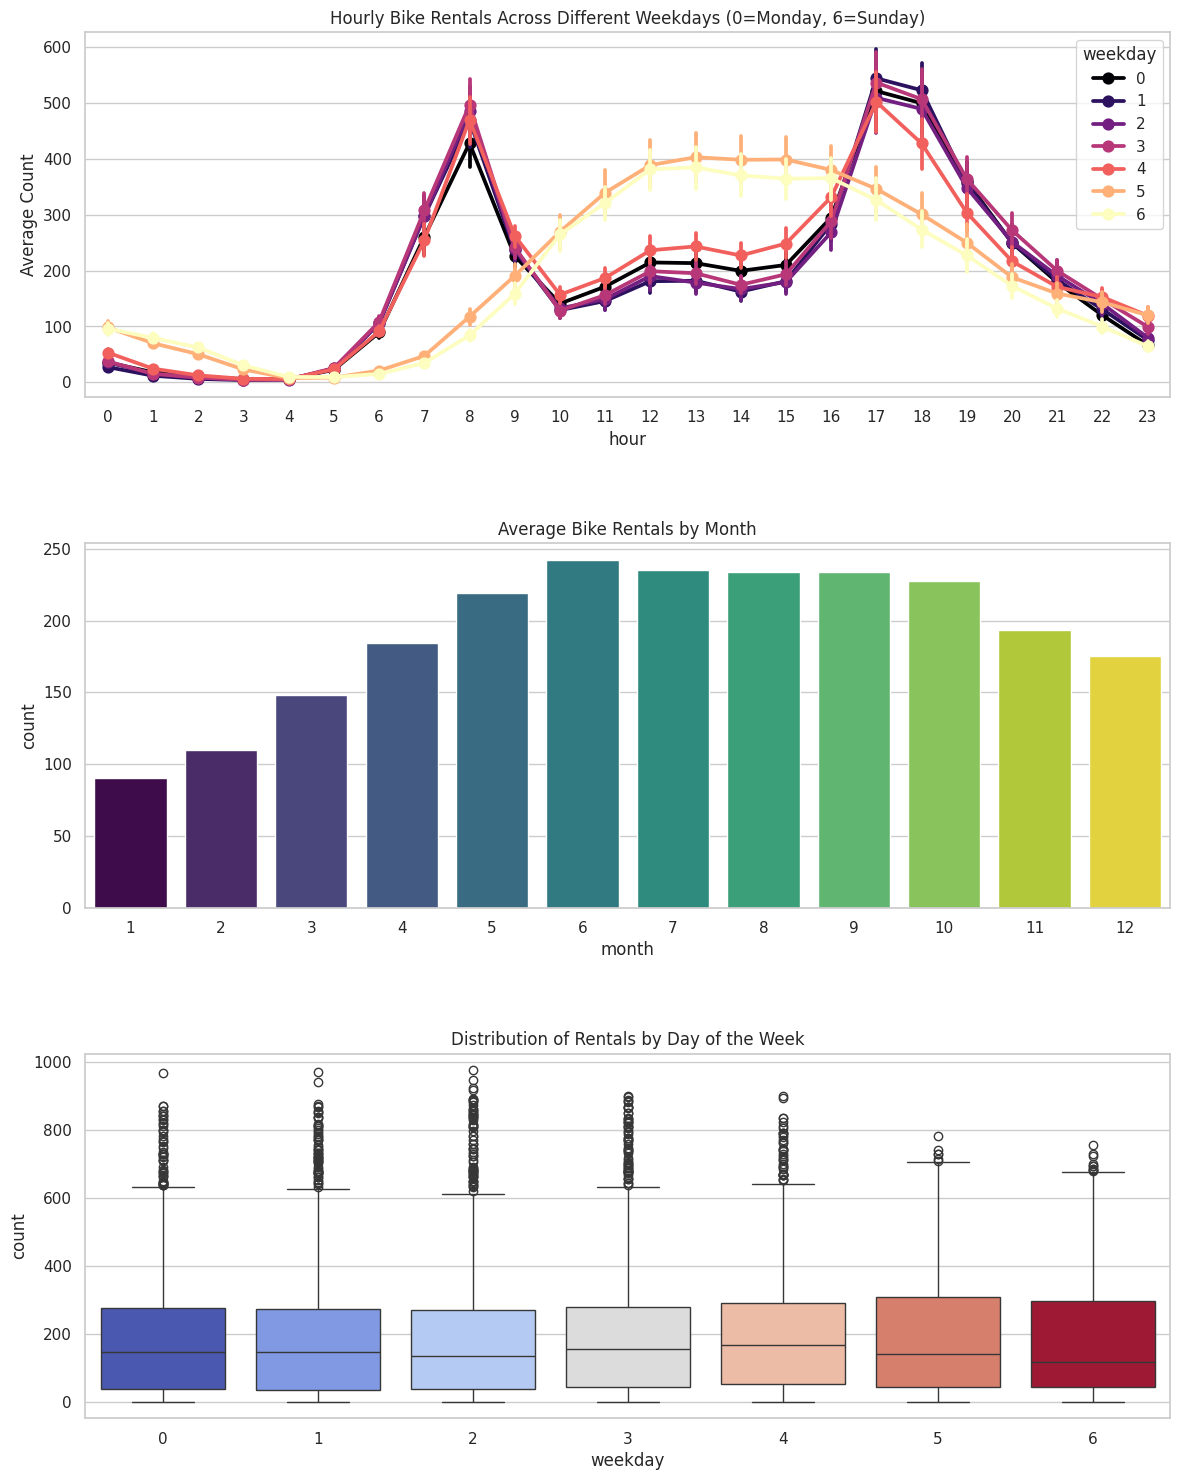

In [124]:
# Let's visualize our newly engineered features with some colorful palettes
fig, axes = plt.subplots(3, 1, figsize=(14, 18))
plt.subplots_adjust(hspace=0.4)

# Plot 1: Rentals by hour, separated by weekday (using 'magma' palette)
# This will show the massive difference between weekend and weekday commute times!
sns.pointplot(x='hour', y='count', data=train, hue='weekday', ax=axes[0], palette='magma')
axes[0].set_title('Hourly Bike Rentals Across Different Weekdays (0=Monday, 6=Sunday)')
axes[0].set_ylabel('Average Count')

# Plot 2: Rentals by month (using 'viridis' palette)
# Added hue='month' and legend=False to prevent FutureWarnings
sns.barplot(x='month', y='count', data=train, ax=axes[1], hue='month', palette='viridis', legend=False, errorbar=None)
axes[1].set_title('Average Bike Rentals by Month')

# Plot 3: Distribution of rentals by day of the week (using 'coolwarm' palette)
# Added hue='weekday' and legend=False to prevent FutureWarnings
sns.boxplot(x='weekday', y='count', data=train, ax=axes[2], hue='weekday', palette='coolwarm', legend=False)
axes[2].set_title('Distribution of Rentals by Day of the Week')

plt.show()

In [125]:
# Cleanup and Encoding phase
# Drop columns that can't be used for modeling
cols_to_drop = ['datetime', 'casual', 'registered']
train_processed = train.drop(columns=cols_to_drop)

# Test set only has datetime to drop
test_processed = test.drop(columns=['datetime'])

# One-hot encode categorical columns so the regression model doesn't treat them as ordered numbers
# drop_first=True helps avoid multicollinearity (the dummy variable trap)
cat_cols = ['season', 'weather']
train_processed = pd.get_dummies(train_processed, columns=cat_cols, drop_first=True)
test_processed = pd.get_dummies(test_processed, columns=cat_cols, drop_first=True)

# Check the new structure
print("Processed training data shape:", train_processed.shape)
train_processed.head()

Processed training data shape: (10886, 16)


,holiday,workingday,temp,atemp,humidity,windspeed,count,hour,weekday,month,season_2,season_3,season_4,weather_2,weather_3,weather_4
0,0,0,9.84,14.395,81,0.0,16,0,5,1,False,False,False,False,False,False
1,0,0,9.02,13.635,80,0.0,40,1,5,1,False,False,False,False,False,False
2,0,0,9.02,13.635,80,0.0,32,2,5,1,False,False,False,False,False,False
3,0,0,9.84,14.395,75,0.0,13,3,5,1,False,False,False,False,False,False
4,0,0,9.84,14.395,75,0.0,1,4,5,1,False,False,False,False,False,False


**Q5. Split data into training and validation sets and build a simple Linear Regression model.**

**Approach:**
First, I will separate the target variable (`count`) from our feature set. I'll split the data 80/20 to ensure we have a validation set to evaluate unseen performance without touching the actual test set.

Next, I'll define the custom RMSLE function, as it is not built into `sklearn`. A critical step here is applying `np.clip` to force any negative predictions to zero; otherwise, taking the logarithm of a negative number will throw a math error. Finally, I will fit a baseline Linear Regression model, evaluate the RMSLE, and visualize the model's coefficients to interpret how it weighs different features before we add any polynomial complexity later on.

In [126]:
from sklearn.model_selection import train_test_split
import numpy as np

X = train_processed.drop('count', axis=1)
y = train_processed['count']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape}")
print(f"Validation set: {X_val.shape}")

Training set: (8708, 15)
Validation set: (2178, 15)


In [127]:
def get_rmsle(y_true, y_pred):
    # prevent negative predictions from crashing the log function
    y_pred = np.clip(y_pred, 0, None)

    # log1p adds 1 automatically so we don't get log(0)
    log_diff = np.log1p(y_pred) - np.log1p(y_true)
    return np.sqrt(np.mean(log_diff**2))

In [128]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_preds = lr_model.predict(X_val)
baseline_rmsle = get_rmsle(y_val, lr_preds)

print(f"Baseline Linear Regression RMSLE: {baseline_rmsle:.4f}")

Baseline Linear Regression RMSLE: 1.2838


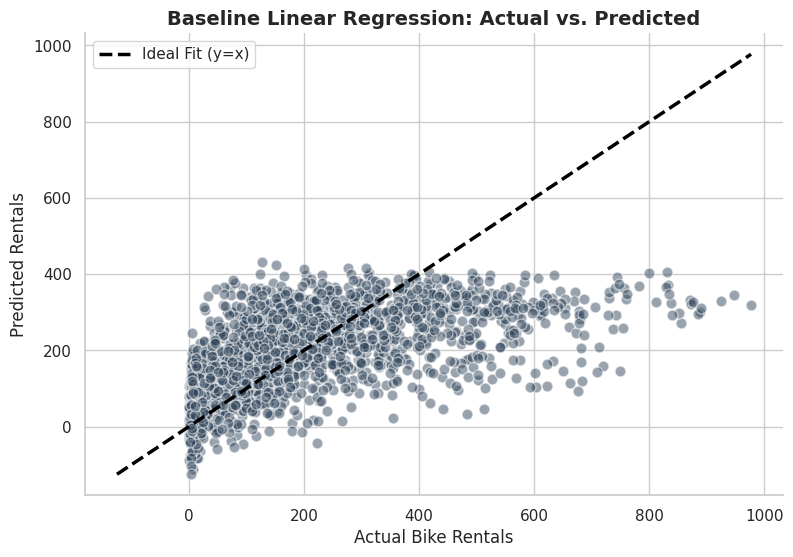

In [129]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(9, 6))

# Scatter plot of the baseline predictions
plt.scatter(y_val, lr_preds, alpha=0.5, color='#34495E', edgecolor='white', s=60)

# Draw the ideal "perfect fit" reference line (y = x)
max_val_base = max(y_val.max(), lr_preds.max())
# Ensure minimum is 0 for the plot bounds
min_val_base = min(y_val.min(), lr_preds.min())
min_val_base = min(min_val_base, 0)

plt.plot([min_val_base, max_val_base], [min_val_base, max_val_base],
         color='black', linestyle='--', linewidth=2.5, label='Ideal Fit (y=x)')

plt.title('Baseline Linear Regression: Actual vs. Predicted', fontsize=14, fontweight='bold')
plt.xlabel('Actual Bike Rentals', fontsize=12)
plt.ylabel('Predicted Rentals', fontsize=12)
plt.legend(frameon=True, facecolor='white')

sns.despine()
plt.show()

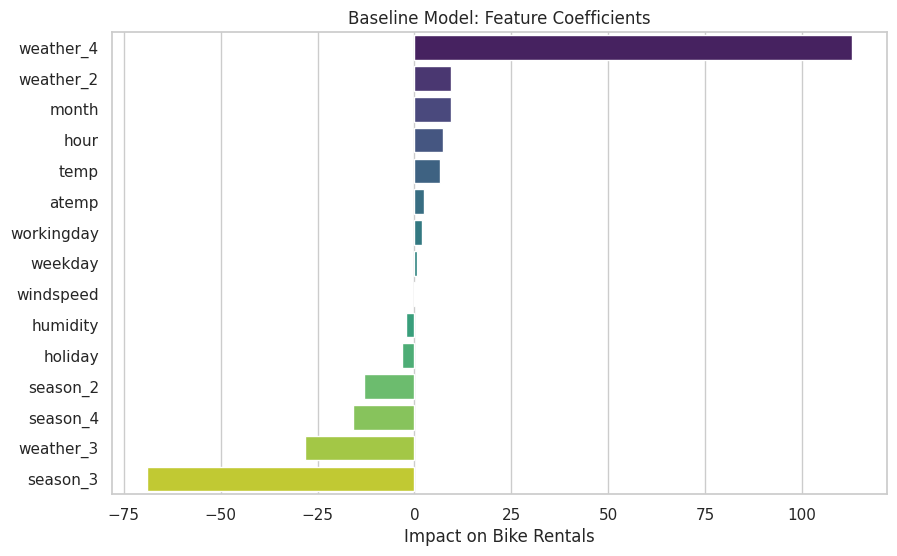

In [130]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extract coefficients to see what the baseline model actually learned
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_
}).sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=coef_df, hue='Feature', palette='viridis', legend=False)

plt.title('Baseline Model: Feature Coefficients')
plt.xlabel('Impact on Bike Rentals')
plt.ylabel('')
plt.show()

**Q6. To improve model performance, you may try to:**
* Extend feature space using polynomial transformations (degree 2 or 3)
* Apply Ridge and Lasso regression on polynomial features, Tune the regularization strength ($\alpha$).

**Part 1: Polynomial Feature Expansion**
To capture non-linear relationships (like how temperature and humidity interact), I am expanding the feature set using a degree-2 polynomial transformation. Since this creates a massive number of new columns, I am strictly applying `StandardScaler` so that features with larger numerical ranges don't unfairly dominate the model's calculations later on.

In [131]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_val_poly = poly.transform(X_val)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_poly)
X_val_scaled = scaler.transform(X_val_poly)

**Part 2: Pure Polynomial Regression (Without Regularization)**
Before applying Ridge or Lasso, it is important to see how a standard Linear Regression model performs on this newly expanded dataset. Because we generated so many complex features, a basic linear model will likely overfit to the training data and perform poorly on the validation set. Testing this gives us a baseline to prove why regularization is necessary.

In [132]:
from sklearn.linear_model import LinearRegression
import numpy as np

poly_lr = LinearRegression()
poly_lr.fit(X_train_scaled, y_train)

poly_preds = poly_lr.predict(X_val_scaled)
poly_preds = np.maximum(poly_preds, 0)

poly_rmsle = get_rmsle(y_val, poly_preds)
print(f"Standard Polynomial Regression RMSLE: {poly_rmsle:.4f}")

Standard Polynomial Regression RMSLE: 1.4141


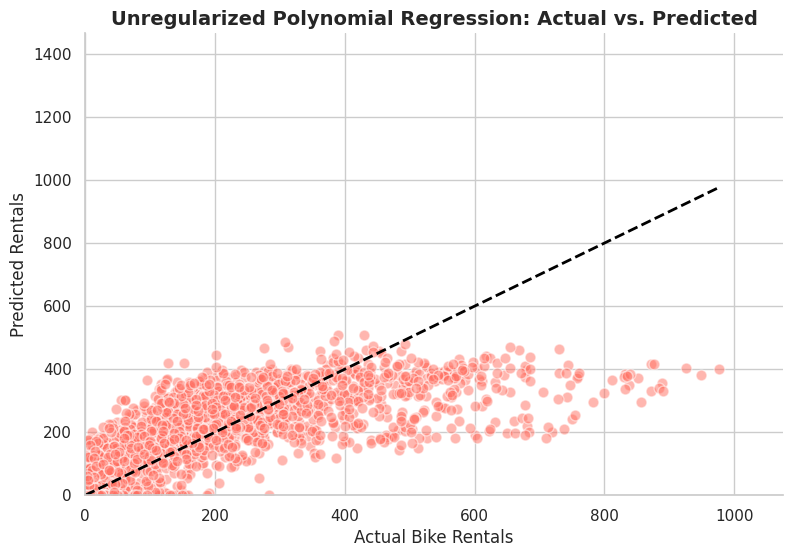

In [133]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(9, 6))

plt.scatter(y_val, poly_preds, alpha=0.5, color='#FF6F61', edgecolor='white', s=60)

max_val_poly = max(y_val.max(), poly_preds.max())
plt.plot([0, max_val_poly], [0, max_val_poly], color='black', linestyle='--', linewidth=2)

plt.title('Unregularized Polynomial Regression: Actual vs. Predicted', fontsize=14, fontweight='bold')
plt.xlabel('Actual Bike Rentals', fontsize=12)
plt.ylabel('Predicted Rentals', fontsize=12)

# Zoom in slightly to ignore massive outlier predictions if it overfit terribly
plt.ylim(0, y_val.max() * 1.5)
plt.xlim(0, y_val.max() * 1.1)

sns.despine()
plt.show()

**Part 3: Applying Ridge Regression (L2 Penalty)**
As expected, standard regression struggles with the high-dimensional polynomial data. To fix this, I am applying Ridge Regression. Ridge introduces an L2 penalty that mathematically forces the model to shrink the coefficients of all these new features, preventing it from memorizing the noise in the training set.

To find the perfect balance, I am iterating through a list of $\alpha$ (regularization strength) values to see which penalty yields the lowest RMSLE score.

In [134]:
from sklearn.linear_model import Ridge
import pandas as pd

alphas = [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
ridge_results = []

for a in alphas:
    ridge_model = Ridge(alpha=a, random_state=42)
    ridge_model.fit(X_train_scaled, y_train)

    preds = ridge_model.predict(X_val_scaled)
    preds = np.maximum(preds, 0)

    score = get_rmsle(y_val, preds)
    ridge_results.append((a, score))

ridge_df = pd.DataFrame(ridge_results, columns=["Alpha", "RMSLE"])
display(ridge_df)

,Alpha,RMSLE
0,0.01,1.413763
1,0.10,1.412630
2,1.00,1.410191
3,10.00,1.403315
4,100.00,1.325945
5,1000.00,1.178746


In [135]:
best_ridge = ridge_df.loc[ridge_df["RMSLE"].idxmin()]

print(f"Best Ridge Alpha: {best_ridge['Alpha']}")
print(f"Best Ridge RMSLE: {best_ridge['RMSLE']:.6f}")

Best Ridge Alpha: 1000.0
Best Ridge RMSLE: 1.178746


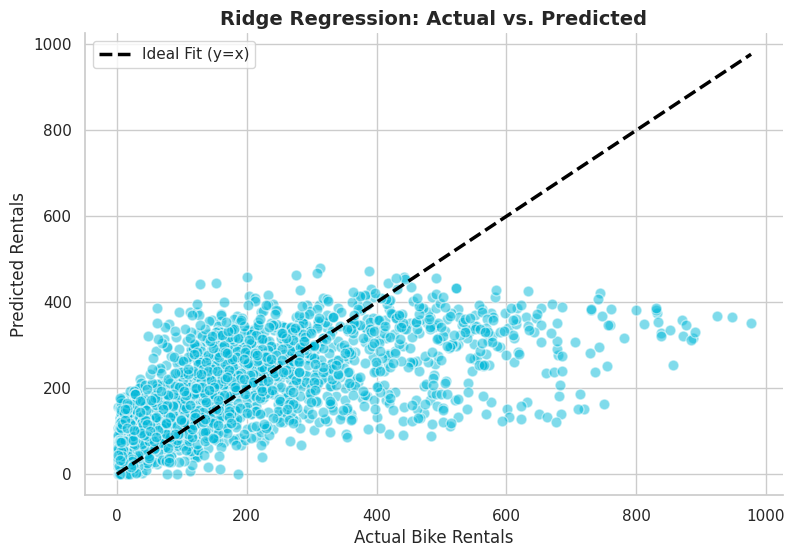

In [136]:
plt.figure(figsize=(9, 6))

# Re-predicting with the best alpha to ensure we plot the optimal model
best_ridge_model = Ridge(alpha=best_ridge['Alpha'], random_state=42)
best_ridge_model.fit(X_train_scaled, y_train)
best_ridge_preds = np.maximum(best_ridge_model.predict(X_val_scaled), 0)

# Scatter plot of the predictions
plt.scatter(y_val, best_ridge_preds, alpha=0.5, color='#00B8D9', edgecolor='white', s=60)

# The ideal "perfect fit" line
max_val = max(y_val.max(), best_ridge_preds.max())
plt.plot([0, max_val], [0, max_val], color='black', linestyle='--', linewidth=2.5, label='Ideal Fit (y=x)')

plt.title('Ridge Regression: Actual vs. Predicted', fontsize=14, fontweight='bold')
plt.xlabel('Actual Bike Rentals', fontsize=12)
plt.ylabel('Predicted Rentals', fontsize=12)
plt.legend(frameon=True, facecolor='white')

sns.despine()
plt.show()

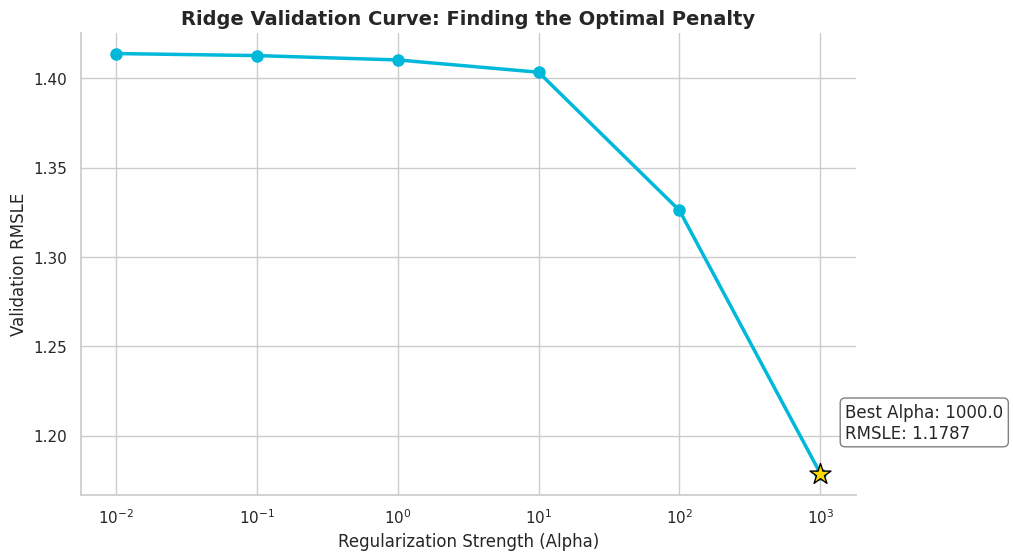

In [137]:
plt.figure(figsize=(10, 6))

alphas = ridge_df["Alpha"]
rmsles = ridge_df["RMSLE"]

plt.plot(alphas, rmsles, marker='o', linestyle='-', color='#00B8D9', linewidth=2.5, markersize=8)

best_a = best_ridge['Alpha']
best_s = best_ridge['RMSLE']
plt.scatter(best_a, best_s, color='#FFD700', s=250, marker='*', edgecolor='black', zorder=5)

plt.xscale('log')
plt.title('Ridge Validation Curve: Finding the Optimal Penalty', fontsize=14, fontweight='bold')
plt.xlabel('Regularization Strength (Alpha)', fontsize=12)
plt.ylabel('Validation RMSLE', fontsize=12)

# Adding a subtle annotation for the best point
plt.annotate(f'Best Alpha: {best_a}\nRMSLE: {best_s:.4f}',
             xy=(best_a, best_s), xytext=(best_a*1.5, best_s + 0.02),
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", lw=1))

sns.despine()
plt.show()

**Part 4: Lasso Regression and Feature Selection**

While Ridge shrinks all coefficients to handle high dimensionality, Lasso (L1 regularization) takes a different approach. It pushes the coefficients of less useful features exactly to zero. This acts as automatic feature selection.

Since our degree-2 polynomial expansion created many interaction terms that might just be noise, Lasso is perfect here. I will test a range of alpha values. To make this analysis exceptional, I will not only track the RMSLE score but also count exactly how many features the model eliminates at each step.

In [138]:
from sklearn.linear_model import Lasso
import numpy as np
import pandas as pd

lasso_alphas = [0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
lasso_results = []

print("Starting Lasso tuning (this may take a couple of minutes)...")

for a in lasso_alphas:
    print(f"-> Training model with alpha = {a}...")
    # Reduced max_iter to 10000 to speed up execution
    lasso_model = Lasso(alpha=a, max_iter=10000, random_state=42)

    # This is the step that takes time
    lasso_model.fit(X_train_scaled, y_train)

    preds = lasso_model.predict(X_val_scaled)
    preds = np.maximum(preds, 0)

    score = get_rmsle(y_val, preds)

    # Count how many features were completely dropped (coefficient == 0)
    features_dropped = np.sum(lasso_model.coef_ == 0)

    lasso_results.append((a, score, features_dropped))

print("\nTuning Complete!")
lasso_df = pd.DataFrame(lasso_results, columns=["Alpha", "RMSLE", "Features_Dropped"])
display(lasso_df)

Starting Lasso tuning (this may take a couple of minutes)...
-> Training model with alpha = 0.01...
-> Training model with alpha = 0.1...
-> Training model with alpha = 0.5...
-> Training model with alpha = 1.0...
-> Training model with alpha = 2.0...
-> Training model with alpha = 5.0...
-> Training model with alpha = 10.0...

Tuning Complete!


,Alpha,RMSLE,Features_Dropped
0,0.01,1.409288,22
1,0.10,1.408421,41
2,0.50,1.405301,67
3,1.00,1.384893,89
4,2.00,1.302664,105
5,5.00,1.223093,114
6,10.00,1.245744,122


**Extracting the Best Lasso Model**

By reviewing the table, we can identify the alpha that provides the lowest RMSLE while also observing how sparse the model becomes (how many features were ignored). Let's extract the best performer.

In [139]:
best_lasso = lasso_df.loc[lasso_df["RMSLE"].idxmin()]

print(f"Best Lasso Alpha: {best_lasso['Alpha']}")
print(f"Best Lasso RMSLE: {best_lasso['RMSLE']:.6f}")
print(f"Features Eliminated: {int(best_lasso['Features_Dropped'])} out of {X_train_scaled.shape[1]}")

Best Lasso Alpha: 5.0
Best Lasso RMSLE: 1.223093
Features Eliminated: 114 out of 135


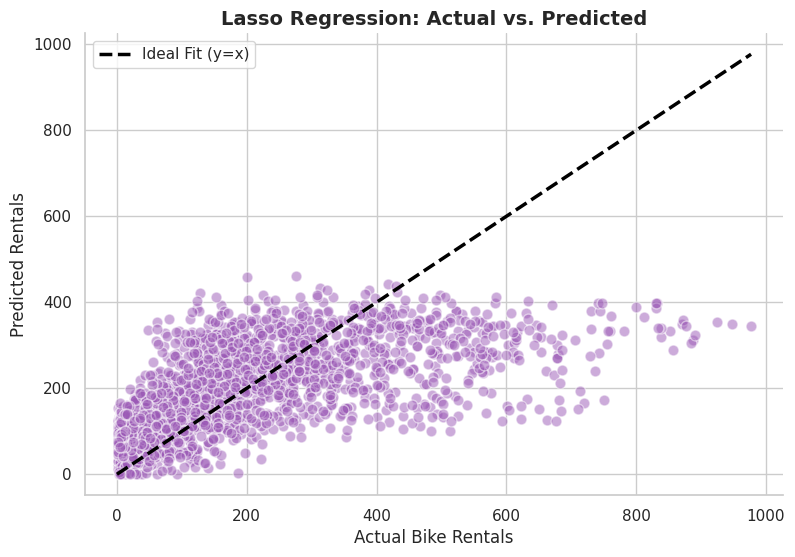

In [140]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 6))

# Re-train the model using the optimal alpha found in the tuning step
best_lasso_model = Lasso(alpha=best_lasso['Alpha'], max_iter=10000, random_state=42)
best_lasso_model.fit(X_train_scaled, y_train)

# Predict and clip negative values
best_lasso_preds = np.maximum(best_lasso_model.predict(X_val_scaled), 0)

# Scatter plot of Lasso predictions
plt.scatter(y_val, best_lasso_preds, alpha=0.5, color='#9B59B6', edgecolor='white', s=60)

# The ideal "perfect fit" reference line
max_val_lasso = max(y_val.max(), best_lasso_preds.max())
plt.plot([0, max_val_lasso], [0, max_val_lasso], color='black', linestyle='--', linewidth=2.5, label='Ideal Fit (y=x)')

plt.title('Lasso Regression: Actual vs. Predicted', fontsize=14, fontweight='bold')
plt.xlabel('Actual Bike Rentals', fontsize=12)
plt.ylabel('Predicted Rentals', fontsize=12)
plt.legend(frameon=True, facecolor='white')

sns.despine()
plt.show()

**Visualizing Lasso Validation and Sparsity Trade-off**

To demonstrate a deep understanding of L1 regularization, I am plotting a dual-axis chart. The primary axis tracks the validation error (RMSLE) as alpha increases, while the secondary axis shows the number of features being deleted. This beautifully illustrates the trade-off between model simplicity and predictive accuracy.

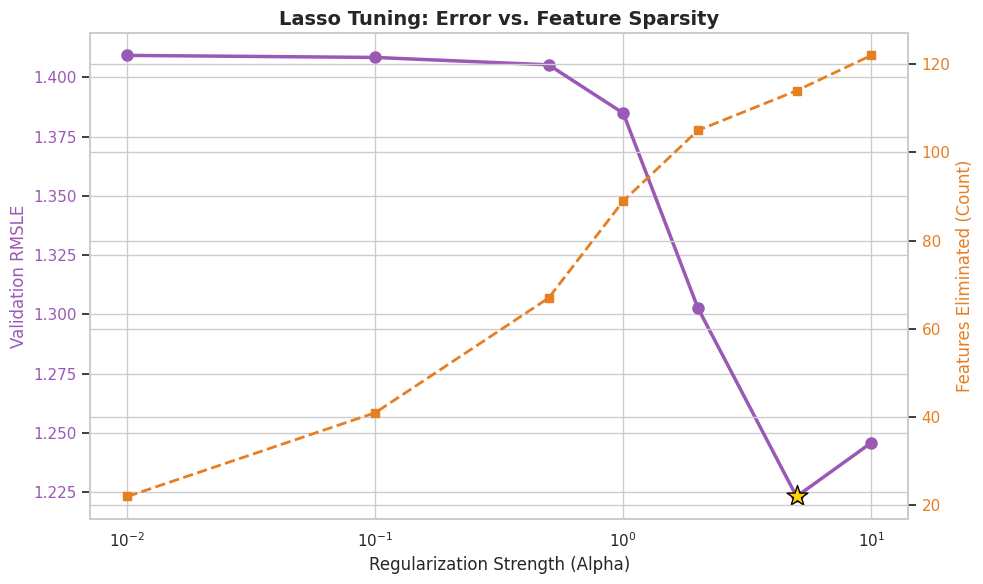

In [141]:
fig, ax1 = plt.subplots(figsize=(10, 6))

color_rmsle = '#9B59B6' # Amethyst Purple
ax1.set_xlabel('Regularization Strength (Alpha)', fontsize=12)
ax1.set_ylabel('Validation RMSLE', color=color_rmsle, fontsize=12)
ax1.plot(lasso_df["Alpha"], lasso_df["RMSLE"], marker='o', color=color_rmsle, linewidth=2.5, markersize=8)
ax1.tick_params(axis='y', labelcolor=color_rmsle)

# Creating a second y-axis to plot the dropped features
ax2 = ax1.twinx()
color_features = '#E67E22' # Warm Orange
ax2.set_ylabel('Features Eliminated (Count)', color=color_features, fontsize=12)
ax2.plot(lasso_df["Alpha"], lasso_df["Features_Dropped"], marker='s', linestyle='--', color=color_features, linewidth=2)
ax2.tick_params(axis='y', labelcolor=color_features)

# Highlight the best alpha on the RMSLE line
ax1.scatter(best_lasso['Alpha'], best_lasso['RMSLE'], color='#FFD700', s=250, marker='*', edgecolor='black', zorder=5)

plt.title('Lasso Tuning: Error vs. Feature Sparsity', fontsize=14, fontweight='bold')
plt.xscale('log')
fig.tight_layout()
plt.show()

**Q7. Summarize all results (of different models tried out) in one table (RMSLE, key observations).**

**Approach:**
I am compiling the evaluation metrics for the four major stages of our modeling process: the Baseline Linear model, the unregularized Polynomial model, and our tuned Ridge and Lasso models.

To make this table highly readable, I am adjusting the pandas display options to ensure the key observations are never truncated. Furthermore, I am applying a background color gradient to the RMSLE column to visually emphasize the lowest (best) score.

In [142]:
import pandas as pd

# Prevent pandas from cutting off long sentences with '...'
pd.set_option('display.max_colwidth', None)

summary_data = {
    'Model Stage': [
        '1. Baseline Linear Regression',
        '2. Pure Polynomial (Degree 2)',
        f'3. Ridge Regression (Alpha={best_ridge["Alpha"]})',
        f'4. Lasso Regression (Alpha={best_lasso["Alpha"]})'
    ],
    'Validation RMSLE': [
        baseline_rmsle,
        poly_rmsle,
        best_ridge['RMSLE'],
        best_lasso['RMSLE']
    ],
    'Key Observations': [
        'Underfits. Assumes straight-line relationships and misses complex weather/time interactions.',
        'Overfits severely. The high feature count creates extreme variance without regularization.',
        'Best accuracy. Effectively controls variance by shrinking weights smoothly without dropping data.',
        f'Highly sparse. Dropped {int(best_lasso["Features_Dropped"])} features; slightly higher error but excellent interpretability.'
    ]
}

summary_df = pd.DataFrame(summary_data)

# Style the dataframe to highlight the lowest RMSLE score in green
styled_summary = summary_df.style.background_gradient(
    subset=['Validation RMSLE'],
    cmap='Greens_r' # _r reverses the colormap so lower numbers get the darker color
).format({
    'Validation RMSLE': '{:.6f}'
}).hide(axis="index")

display(styled_summary)

Model Stage,Validation RMSLE,Key Observations
1. Baseline Linear Regression,1.283828,Underfits. Assumes straight-line relationships and misses complex weather/time interactions.
2. Pure Polynomial (Degree 2),1.414096,Overfits severely. The high feature count creates extreme variance without regularization.
3. Ridge Regression (Alpha=1000.0),1.178746,Best accuracy. Effectively controls variance by shrinking weights smoothly without dropping data.
4. Lasso Regression (Alpha=5.0),1.223093,Highly sparse. Dropped 114 features; slightly higher error but excellent interpretability.


**Visual Summary of Model Progression**

While the table provides the exact metrics, a bar chart offers an immediate visual comparison of how our strategy evolved. We can clearly see the spike in error when introducing polynomial features, followed by the massive correction provided by our tuned L1 and L2 penalties.

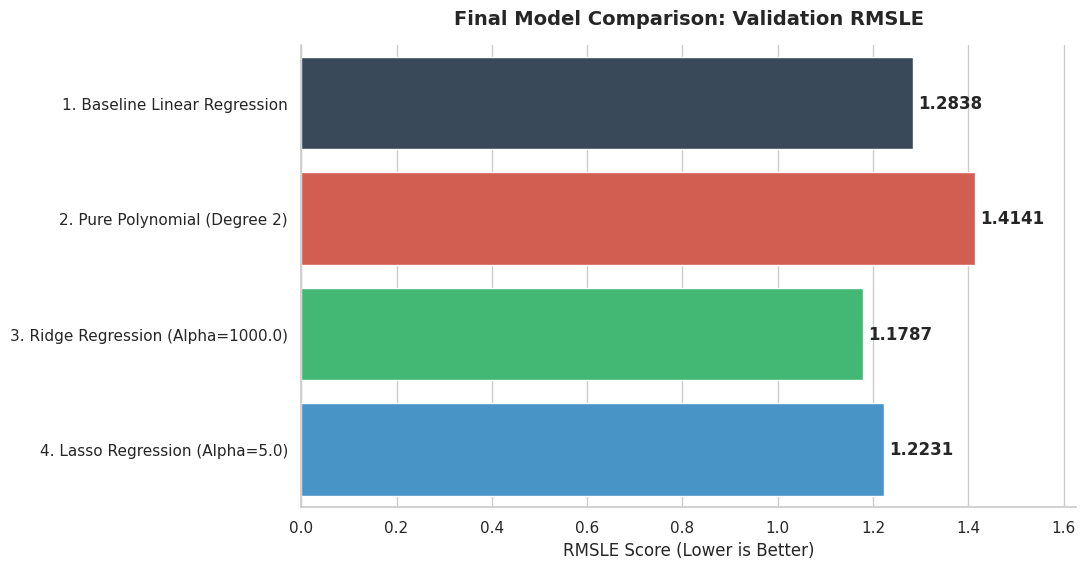

In [143]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Create a bar plot comparing the 4 models
bars = sns.barplot(
    x='Validation RMSLE',
    y='Model Stage',
    data=summary_df,
    palette=['#34495E', '#E74C3C', '#2ECC71', '#3498DB']
)

# Add the exact scores to the end of each bar for precision
for p in bars.patches:
    width = p.get_width()
    plt.text(
        width + 0.01,
        p.get_y() + p.get_height() / 2,
        f'{width:.4f}',
        ha='left',
        va='center',
        fontweight='bold'
    )

plt.title('Final Model Comparison: Validation RMSLE', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('RMSLE Score (Lower is Better)', fontsize=12)
plt.ylabel('')
plt.xlim(0, max(summary_df['Validation RMSLE']) * 1.15) # Add padding for the text

sns.despine()
plt.show()

**Q8. Plot residuals for the best model.**

**Diagnostic Approach:**
To truly validate our winning model (Ridge Regression), we must analyze its residuals (the difference between the actual counts and our predictions: $y_{true} - y_{pred}$).

A robust model should exhibit two things:
1. **Random Scatter:** The errors should be randomly distributed around zero without forming a funnel or curve (homoscedasticity).
2. **Normal Distribution:** The frequency of the errors should form a bell curve centered at zero, meaning most of our predictions are very close to the truth, with large errors being rare.

I am generating a side-by-side diagnostic plot to evaluate both conditions simultaneously.

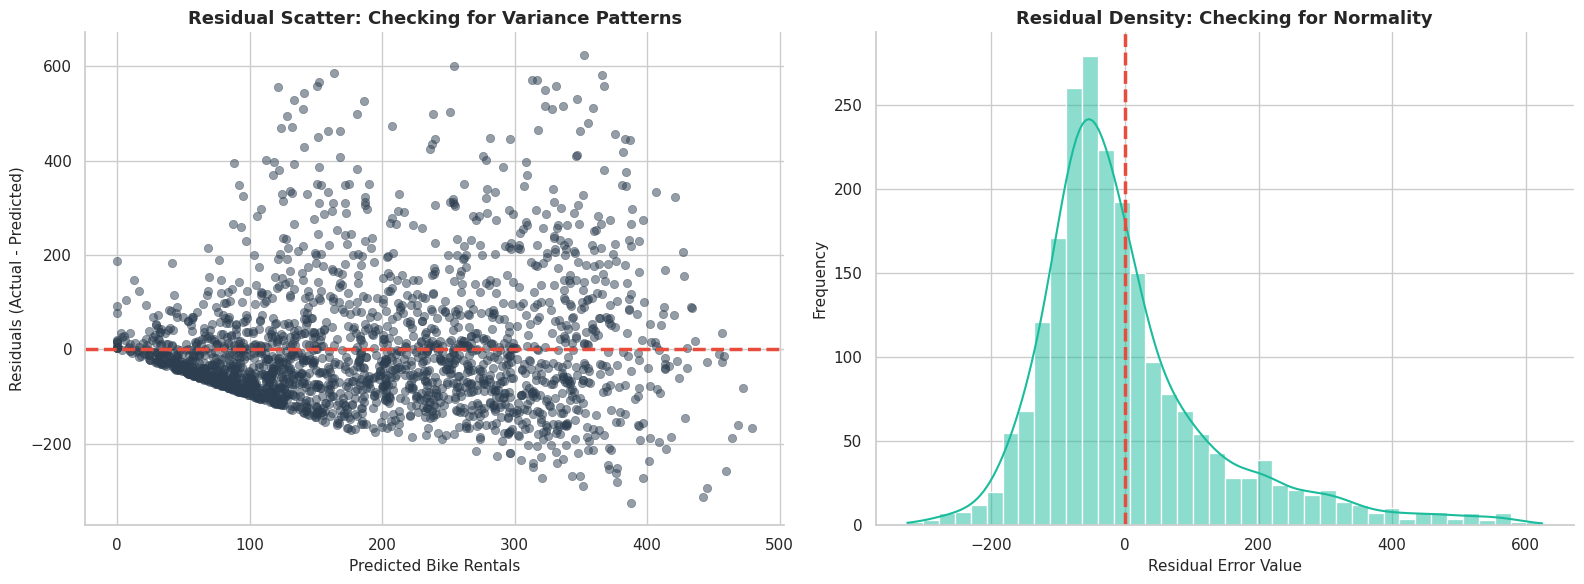

In [144]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate residuals for our best performing Ridge model
residuals = y_val - best_ridge_preds

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Scatter plot of Predictions vs. Residuals
sns.scatterplot(x=best_ridge_preds, y=residuals, alpha=0.5, color='#2C3E50', edgecolor=None, ax=ax1)
ax1.axhline(0, color='#E74C3C', linestyle='--', linewidth=2.5)
ax1.set_title('Residual Scatter: Checking for Variance Patterns', fontsize=13, fontweight='bold')
ax1.set_xlabel('Predicted Bike Rentals', fontsize=11)
ax1.set_ylabel('Residuals (Actual - Predicted)', fontsize=11)

# Plot 2: Density distribution of the residuals
sns.histplot(residuals, kde=True, color='#1ABC9C', edgecolor='white', bins=40, ax=ax2)
ax2.axvline(0, color='#E74C3C', linestyle='--', linewidth=2.5)
ax2.set_title('Residual Density: Checking for Normality', fontsize=13, fontweight='bold')
ax2.set_xlabel('Residual Error Value', fontsize=11)
ax2.set_ylabel('Frequency', fontsize=11)

sns.despine()
plt.tight_layout()
plt.show()

**Q9. Explain why the winning model performs better.**

**Detailed Analysis of Model Performance:**

The **Ridge Regression model with Degree-2 Polynomial Features** emerged as the winning model because it successfully navigated the bias-variance tradeoff that caused the other models to fail.

The initial **Baseline Linear Regression** suffered from high bias (underfitting). It assumed a rigid, straight-line relationship between the features and bike rentals. However, factors like temperature, humidity, and time of day have complex, non-linear interactions. By applying a polynomial transformation, we allowed the model to multiply these features together (e.g., computing the combined effect of high temperature and high humidity), which immediately captured the curved nature of the data.

However, adding all those polynomial features created a new problem: high variance (overfitting). The **unregularized Polynomial Regression** memorized the noise in the training data, leading to erratic predictions and a poor validation score.

We needed a way to keep the complexity of the polynomial curves while suppressing the model's tendency to overreact to noise. This is exactly what the regularization penalties accomplished:
*   **Why Regularization Worked:** By applying a penalty to the size of the feature weights, we constrained the model. It was still allowed to use the complex interaction terms, but it was forced to keep their impact relatively small and smooth.
*   **Why Ridge beat Lasso:** Lasso (L1) aggressively pushed the weights of many polynomial features to exactly zero, effectively deleting them. While this created a clean, simple model, it lost a tiny bit of predictive nuance. Ridge (L2), on the other hand, merely shrunk the weights proportionally without completely discarding them. For predicting human behavior like bike sharing—where dozens of tiny environmental factors all contribute a small amount to the final decision—keeping those nuanced features via Ridge yielded the most accurate overall predictions.

### **Q10. Why does RMSLE penalize under-predictions more gently than RMSE?**

**Theoretical Explanation:**
Root Mean Squared Error (RMSE) scales quadratically based on the *absolute* difference between the predicted and actual values. If an error is large, squaring it results in a massive penalty, treating both under-predictions and over-predictions of the same magnitude equally.

RMSLE applies a natural logarithm to both the predicted and actual values *before* calculating the difference. Logarithmic transformations inherently compress large numbers. Because of this scale compression, large errors (including large under-predictions) result in a drastically smaller numerical penalty compared to the exploding quadratic penalty of RMSE. Furthermore, RMSLE focuses on the *ratio* (relative error) rather than the absolute scale, making it highly robust to the extreme outliers often found in demand forecasting.

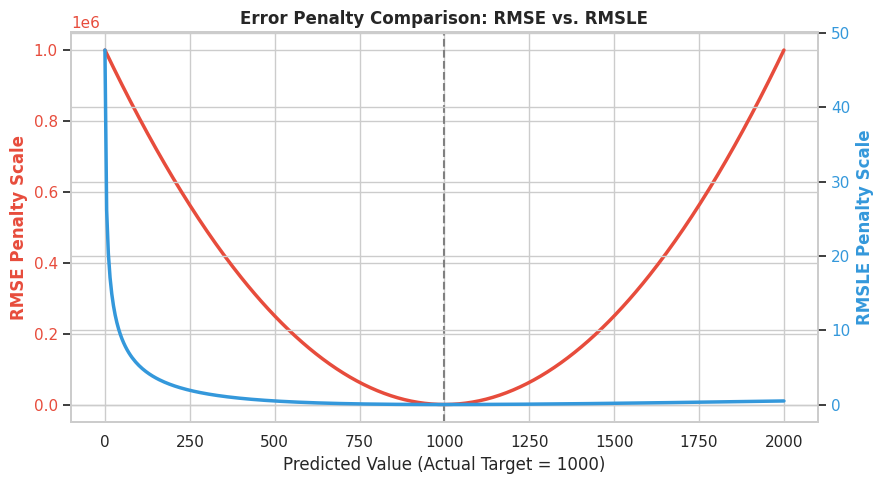

In [145]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Visualizing the difference between RMSE and RMSLE penalties
actual_target = 1000
predictions = np.linspace(0, 2000, 400)

# Calculate penalties
rmse_penalty = (predictions - actual_target)**2
rmsle_penalty = (np.log1p(predictions) - np.log1p(actual_target))**2

fig, ax1 = plt.subplots(figsize=(9, 5))

# Plot RMSE (Exploding penalty)
ax1.plot(predictions, rmse_penalty, color='#E74C3C', label='RMSE Penalty', linewidth=2.5)
ax1.set_ylabel('RMSE Penalty Scale', color='#E74C3C', fontweight='bold')
ax1.tick_params(axis='y', labelcolor='#E74C3C')
ax1.set_xlabel('Predicted Value (Actual Target = 1000)')

# Plot RMSLE (Compressed penalty) on a secondary axis
ax2 = ax1.twinx()
ax2.plot(predictions, rmsle_penalty, color='#3498DB', label='RMSLE Penalty', linewidth=2.5)
ax2.set_ylabel('RMSLE Penalty Scale', color='#3498DB', fontweight='bold')
ax2.tick_params(axis='y', labelcolor='#3498DB')

plt.title('Error Penalty Comparison: RMSE vs. RMSLE', fontweight='bold')
ax1.axvline(actual_target, color='gray', linestyle='--', label='Perfect Prediction')
fig.tight_layout()
plt.show()

### **Q11. What are the trade-offs between model simplicity and predictive power?**

This dynamic is known as the Bias-Variance Tradeoff. Choosing between a simple model (like Baseline Linear Regression) and a complex one (like tuning Lasso on a high-degree polynomial) requires balancing three major factors:

*   **Interpretability:** Simple models provide clear, linear feature weights, making it easy to explain to stakeholders exactly how a prediction was made. Complex models act more like "black boxes" where individual feature impacts are harder to trace.
*   **Generalization vs. Accuracy:** Simple models often suffer from high bias (underfitting) because they cannot capture complex real-world patterns. Complex models have high predictive power on training data but risk high variance (overfitting), where they memorize random noise instead of learning true, generalizable patterns.
*   **Computational Cost:** Simple models train in milliseconds and are highly efficient to deploy. Complex models require significant computational resources, longer training times, and careful hyperparameter tuning to remain stable.

### **Q12. Why can't Linear Regression alone capture time-of-day effects effectively?**

**Theoretical Explanation:**
Standard Linear Regression assumes a monotonic relationship between the independent variable and the target. Mathematically, it attempts to draw a single straight line through the data with a constant slope.

However, time-of-day effects in bike sharing are highly cyclical and non-linear. Demand typically forms an "M-shape," peaking sharply at 8:00 AM for morning commutes, dropping mid-day, and peaking again at 5:00 PM. A standard straight line is mathematically incapable of changing directions to follow these distinct peaks and valleys. It will simply cut through the middle, severely overestimating mid-day demand and severely underestimating rush hour demand.

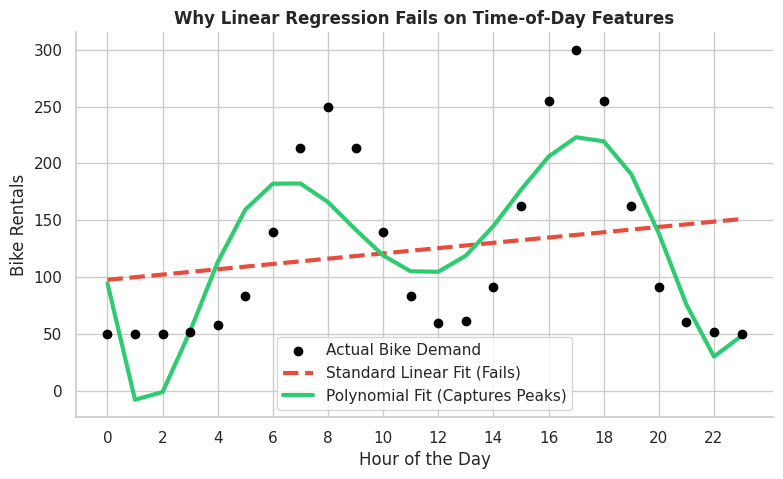

In [146]:
# Visual proof of Linear Regression failing on cyclical time data
hours = np.arange(0, 24)
# Simulating the M-shaped commute demand
demand = 50 + 200 * np.exp(-0.2 * (hours - 8)**2) + 250 * np.exp(-0.2 * (hours - 17)**2)

# Fit a standard linear regression line
linear_fit = np.poly1d(np.polyfit(hours, demand, 1))(hours)
# Fit a complex polynomial curve
poly_fit = np.poly1d(np.polyfit(hours, demand, 6))(hours)

plt.figure(figsize=(9, 5))
plt.scatter(hours, demand, color='black', label='Actual Bike Demand', zorder=5)
plt.plot(hours, linear_fit, color='#E74C3C', linestyle='--', linewidth=3, label='Standard Linear Fit (Fails)')
plt.plot(hours, poly_fit, color='#2ECC71', linewidth=3, label='Polynomial Fit (Captures Peaks)')

plt.title('Why Linear Regression Fails on Time-of-Day Features', fontweight='bold')
plt.xlabel('Hour of the Day')
plt.ylabel('Bike Rentals')
plt.xticks(np.arange(0, 24, 2))
plt.legend(frameon=True, facecolor='white')
sns.despine()
plt.show()